# Imports

In [759]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, classification_report

In [760]:
import warnings
warnings.filterwarnings('ignore')

# Read DF

In [761]:
df = pd.read_csv('/content/synthetic_coffee_health_10000(in).csv')

Sobre as colunas:




*   Coffee_Intake --> Consumo diário de café em xícaras (0 a 10).
*   Caffeine_mg --> Estimativa de cafeína ingerida por dia em mg (1 xícara ≈ 95 mg).
*   BMI --> Índice de Massa Corporal (15 a 40).





In [762]:
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


# Infos Df

In [763]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [764]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [765]:
display('qtd categorias qualidade do sono:', df['Sleep_Quality'].value_counts())
display('pct categorias qualidade do sono:', df['Sleep_Quality'].value_counts(normalize=True))

## um pouco desbalanceado entre as categorias, 56% dos casos com boa qualidade de sono, 20% mediano e os outros 24% distribuidos entre excelente e ruim

'qtd categorias qualidade do sono:'

,count
Sleep_Quality,
Good,5637
Fair,2050
Excellent,1352
Poor,961


'pct categorias qualidade do sono:'

,proportion
Sleep_Quality,
Good,0.5637
Fair,0.2050
Excellent,0.1352
Poor,0.0961


# EDA

In [766]:
df.loc[df['Health_Issues'].isna(), 'Health_Issues'] = 'None'

## Gráficos: Colunas Categóricas

In [767]:
colors_sleep = {
    'Excellent': 'lightgreen',
    'Good': 'lightblue',
    'Fair': 'orange',
    'Poor': 'salmon'
}

colors_stress = {
    'High': 'Salmon',
    'Low': 'lightgreen',
    'Medium': 'orange'
}

<Axes: xlabel='Sleep_Quality'>

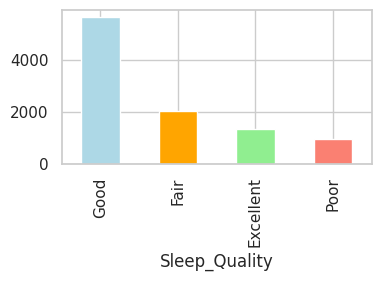

In [768]:
#distribuição das categorias de qualidade de sono
df['Sleep_Quality'].value_counts().plot(kind='bar', color=['lightblue', 'orange', 'lightgreen', 'salmon'], figsize=(4,2))

#bem desbalanceado, 50% dos casos com boa qualidade, 20% medianos e o restante dividido entre excelente e péssimo

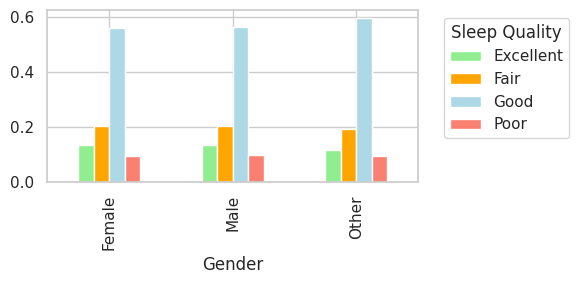

In [769]:
#percentual qualidade de sono por gênero
ax = pd.crosstab(df['Gender'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(6, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

## sem muita diferença entre as categorias

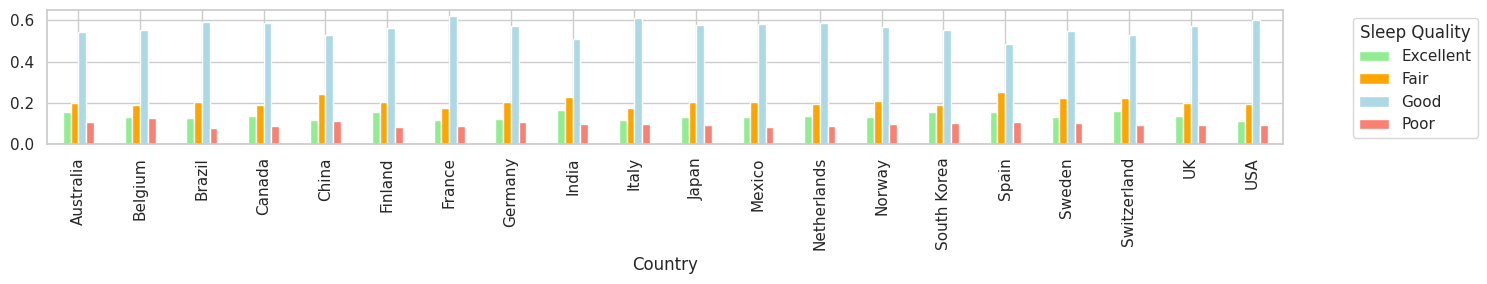

In [770]:
#percentual qualidade de sono por país
ax = pd.crosstab(df['Country'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(15, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

## nada muito absurdo em relação a proporção das categorias e as regiões

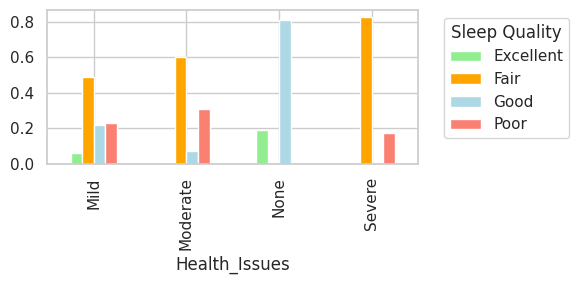

In [771]:
#percentual qualidade de sono por condição de saúde
ax = pd.crosstab(df['Health_Issues'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(6, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

## pessoas com qualidades de sono boa e excelente não tem problemas de saúde, ou talvez tenham boa e excelente qualidade de sono por não ter problemas de saúde, mas a correlação existe.
## o contrário também é verdadeiro, pessoas com pior qualidade de sono tem problemas de saúde severos.

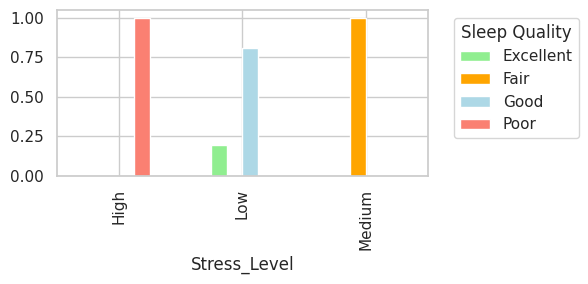

In [772]:
#percentual qualidade de sono por nível de estresse
ax = pd.crosstab(df['Stress_Level'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(6, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

## pessoas mais estressadas tem qualidade de sono péssima enquanto pessoas com melhor qualidade de sono são menos estressadas

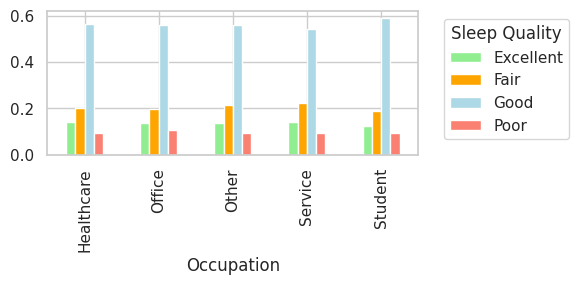

In [773]:
#percentual qualidade de sono por ocupação
ax = pd.crosstab(df['Occupation'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(6, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

#nada muito absurdo em relação a proporção entre as categorias

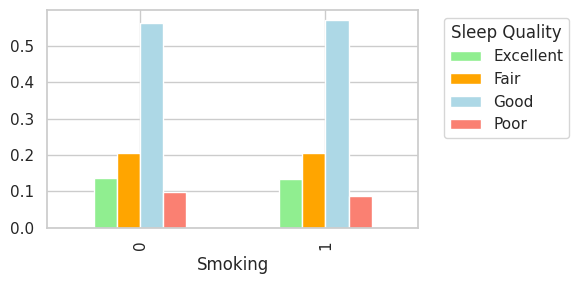

In [774]:
#percentual qualidade de sono em relação a fumantes
ax = pd.crosstab(df['Smoking'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(6, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

#nada muito absurdo em relação a proporção entre as categorias

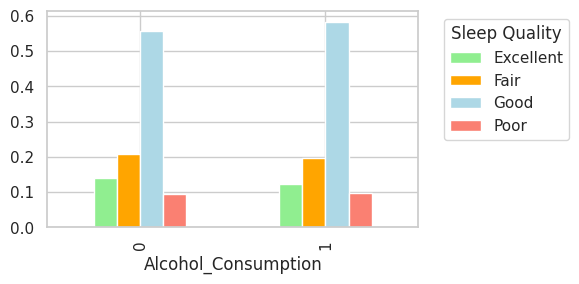

In [775]:
#percentual qualidade de sono em relação ao consumo de álcool
ax = pd.crosstab(df['Alcohol_Consumption'], df['Sleep_Quality'], normalize='index').plot(
    kind='bar',
    color=colors_sleep,
    figsize=(6, 3)
)

ax.legend(title='Sleep Quality', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

#nada muito absurdo em relação a proporção entre as categorias

## Gráficos: Colunas Númericas

<Axes: xlabel='Sleep_Quality', ylabel='Age'>

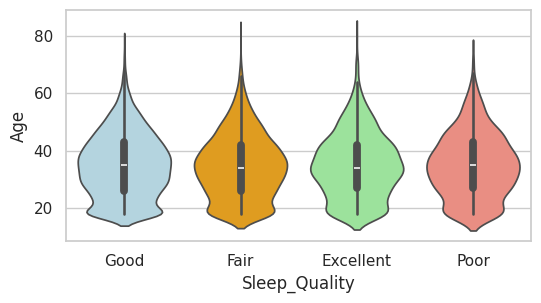

In [776]:
#distribuição de idades em relação as categorias de qualidade de sono
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Sleep_Quality', y='Age', palette=colors_sleep)

##Violin plots muito semelhantes entre si, nada discrepante

<Axes: xlabel='Sleep_Quality', ylabel='Coffee_Intake'>

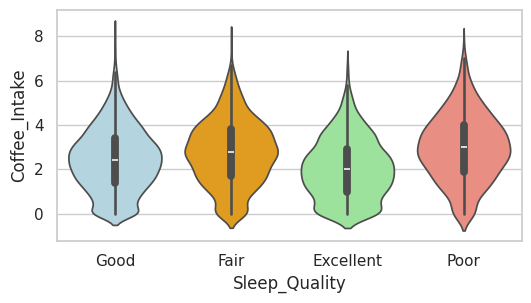

In [777]:
#quantidade de cafeína ingerida em relação as categorias de qualidade de sono
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Sleep_Quality', y='Coffee_Intake', palette=colors_sleep)

## nada muito discrepante entre as categorias mas da pra observar que quem tem qualidade de sono excelente ingere menos cafeína do que quem tem qualidade de sono pior

<Axes: xlabel='Sleep_Quality', ylabel='Sleep_Hours'>

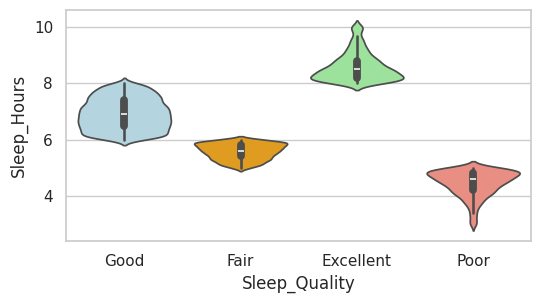

In [778]:
#quantidade de cafeína ingerida em relação as categorias de qualidade de sono
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Sleep_Quality', y='Sleep_Hours', palette=colors_sleep)

## nítida correlação direta entre horas dormidas e qualidade de sono. 6,5 a 7,5 horas de sono para boa qualidade,
## 5 a 6 horas para média, acima de 8 horas para excelente e menos de 5 horas para péssima qualidade

<Axes: xlabel='Sleep_Quality', ylabel='Heart_Rate'>

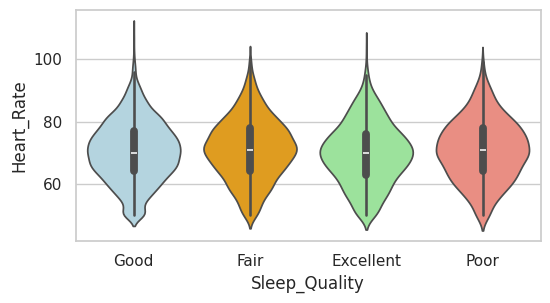

In [779]:
#frequência cardiaca em relação as categorias de qualidade de sono
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Sleep_Quality', y='Heart_Rate', palette=colors_sleep)

## nada discrepante entre as categorias

<Axes: xlabel='Sleep_Quality', ylabel='Physical_Activity_Hours'>

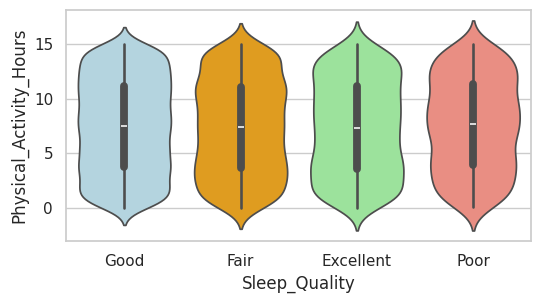

In [780]:
#horas de atividade física em relação as categorias de qualidade de sono
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Sleep_Quality', y='Physical_Activity_Hours', palette=colors_sleep)

## nada muito discrepante em relação as categorias

<Axes: xlabel='Sleep_Quality', ylabel='BMI'>

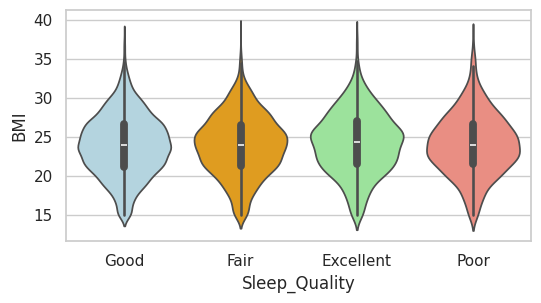

In [781]:
#imc em relação as categorias de qualidade de sono
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Sleep_Quality', y='BMI', palette=colors_sleep)

##nada muito relevante entre as categorias

<Axes: xlabel='Stress_Level', ylabel='Caffeine_mg'>

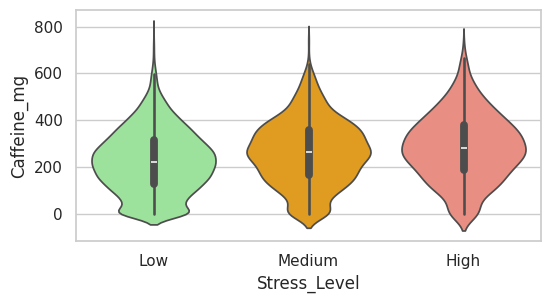

In [782]:
#quantidade de cafeína ingerida em relação as categorias de nível de estresse
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='Stress_Level', y='Caffeine_mg', palette=colors_stress)

##quanto menor a ingestão de cafeína menor o nível de estresse, quanto maior a ingestão de cafeína maior o nível de estresse

## Principais Descobertas


Observando a correlação entre as features através dos gráficos sem muito aprofundamento, segue alguns pontos.:

- qualidade de sono tem correlação direta com condições de saúde, quanto melhor, menos problemas.
- qualidade de sono tem correlação inversa com níveis de estresse, quanto melhor a qualidade de sono, menos níveis de estresse
- apesar de a comparação entre ingestão de cafeína e qualidade de sono não apresentarem resultados tão obvios, nota-se que quanto menor a ingestão de cafeína melhor a qualidade de sono e quanto maior a ingestão de cafeína pior a qualidade de sono
- obviamente horas de sono tem correlação direta com a qualidade, quanto maior, melhor.
- níveis de estresse vs cafeína ingerida também não apresentam resultados tão obvios, mas a principio, quanto menor a ingestão de cafeína, menor o nível de estresse.
- por fim, gênero, região, ocupação, consumo de álcool e cigarro, idade, frequência cardíaca, horas de atividade física e imc não apresentaram correlações relevantes em relação a qualidade de sono.

- coffee_intake e caffeine_mg falam a mesma coisa, não faz sentido manter as duas no df

# Modelos

OBJETIVO:

O time deseja prever a qualidade do sono (Sleep_Quality) com base nos hábitos e características dos clientes.

Nosso último passo será preparar os dados e implementar modelos de classificação.

A atividade

1. Faça o pré-processamento dos dados:
  - Remova ou trate colunas irrelevantes.
  - Aplique codificação em variáveis categóricas.
  - Crie pelo menos uma feature derivada.


2. Divida os dados em treino e teste.


3. Treine pelo menos dois modelos de classificação sendo, Sleep_Quality, a variável alvo (target).
  - Compare resultados usando acurácia, matriz de confusão e/ou relatório de classificação.


4. Documente a avaliação:
  - Qual modelo performou melhor?
  - Há overfitting ou underfitting?


5. Salve o dataset final processado em CSV.


6. Salve o modelo que se saiu melhor.


7. Adicione uma seção Recomendações para o Negócio, explicando como os resultados podem ajudar a empresa a orientar clientes sobre hábitos de café e sono.

## Ajustando Df

####GetDummies

In [783]:
#drop_colunas = ['Sleep_Quality', 'ID']
drop_colunas = ['Sleep_Quality', 'Sleep_Hours','ID', 'Gender', 'Country', 'Caffeine_mg', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption']
#drop em sleep_quality e algumas colunas que considerei irrelevantes

df_X = df.drop(columns=drop_colunas)
df_y = df['Sleep_Quality']

In [784]:
pd.set_option('display.max_columns', None)

In [785]:
#colunas_categoricas = ['Gender', 'Country', 'Stress_Level', 'Health_Issues', 'Occupation']
colunas_categoricas = ['Stress_Level', 'Health_Issues', 'Occupation']
df_X = pd.get_dummies(df_X, columns=colunas_categoricas, dtype=int)

In [786]:
df_X.head(1)

,Age,Coffee_Intake,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium,Health_Issues_Mild,Health_Issues_Moderate,Health_Issues_None,Health_Issues_Severe,Occupation_Healthcare,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student
0,40,3.5,0,1,0,0,0,1,0,0,0,1,0,0


####StandardScaler

In [787]:
sc = StandardScaler()
X_sc = sc.fit_transform(df_X)

In [788]:
df_X_sc = pd.DataFrame(X_sc, columns=df_X.columns)

In [789]:
df_X_sc.head(1)

,Age,Coffee_Intake,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium,Health_Issues_Mild,Health_Issues_Moderate,Health_Issues_None,Health_Issues_Severe,Occupation_Healthcare,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student
0,0.452574,0.683207,-0.326063,0.656369,-0.507801,-0.746585,-0.220336,0.82657,-0.041266,-0.494368,-0.511382,1.976555,-0.493272,-0.494995


####DF's: Treino e Teste

In [790]:
X_train, X_test, y_train, y_test = train_test_split(df_X_sc, df_y, test_size=0.25, random_state=42, stratify=df_y)

In [791]:
print('qtd casos total df:', df_X_sc.shape[0])
print('qtd casos total df_treino:', X_train.shape[0])
print('qtd casos total df_test:', X_test.shape[0])

qtd casos total df: 10000
qtd casos total df_treino: 7500
qtd casos total df_test: 2500


## Treinando os Modelos

In [792]:
nomes_classes = ['Excellent', 'Fair', 'Good', 'Poor']

#### Naive Bayes

In [793]:
from sklearn.naive_bayes import GaussianNB

In [794]:
modelo_nb = GaussianNB()

In [795]:
modelo_nb.fit(X_train, y_train)

GaussianNB()

In [796]:
y_pred = modelo_nb.predict(X_test)

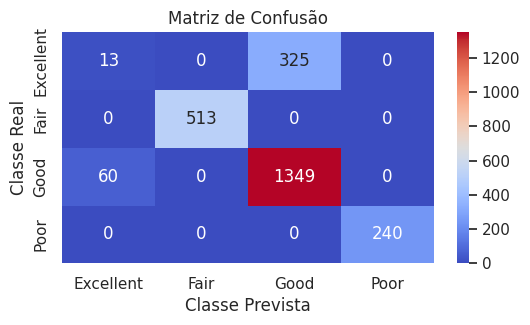

In [797]:
matriz_confusao = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 3))

sns.heatmap(
    matriz_confusao,
    annot=True,
    cmap='coolwarm',
    fmt='d',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show()

In [798]:
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.846


#### Logistic Regression

In [799]:
from sklearn.linear_model import LogisticRegression

In [800]:
modelo_lr = LogisticRegression(random_state=42)

In [801]:
modelo_lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [802]:
y_pred = modelo_lr.predict(X_test)

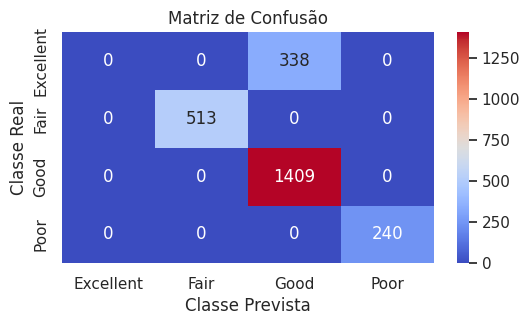

In [803]:
matriz_confusao = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 3))

sns.heatmap(
    matriz_confusao,
    annot=True,
    cmap='coolwarm',
    fmt='d',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show()

In [804]:
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.8648


#### Random Forest

In [805]:
from sklearn.ensemble import RandomForestClassifier

In [806]:
modelo_rf = RandomForestClassifier(random_state=42)

In [807]:
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [808]:
y_pred = modelo_rf.predict(X_test)

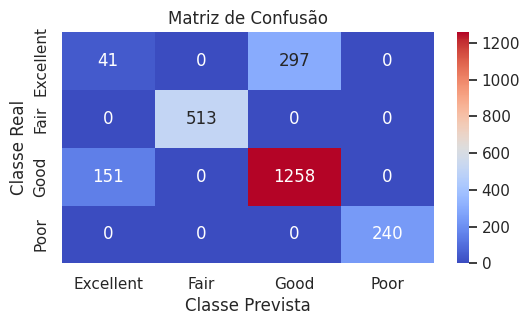

In [809]:
matriz_confusao = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 3))

sns.heatmap(
    matriz_confusao,
    annot=True,
    cmap='coolwarm',
    fmt='d',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show()

In [810]:
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.8208


## Resumo

Depois de retirada algumas colunas desnecessárias e a coluna 'Sleep_Hours' (basicamente uma cola do resultado), o modelo que melhor performou foi o Logistic Regression com 86% de acurácia, contra 84% Naive Bayes e 82% Random Forest.

Vale ressaltar que apesar do melhor desempenho o modelo não classificou nenhum caso na categoria excelente, muito provavelmente devido ao desbalanceamento dos dados. Já o Naive Bayes mesmo que erroneamente classificou alguns casos.

Todos os modelos foram testados com os hiperparâmetros default, sem tentativas de ajustes ou melhorias, nem mesmo balanceamento da base, a intenção era comparar o desempenho dos modelos nessas condições.


* um ponto a ressaltar. Mantendo a coluna 'Sleep_Hours' temos um cenário de overfitting, já que ela e 'Sleep_Quality' possuem uma relação entre si muito parecida com a relação entre as colunas 'Coffee_Intake' e 'Caffeine_mg'

## salvando dataset


In [811]:
#X_train.to_csv('X_treino.csv', index=False)
#X_test.to_csv('X_teste.csv', index=False)

#y_train.to_csv('y_treino.csv', index=False)
#y_test.to_csv('y_teste.csv', index=False)

## Recomendações para o Negócio

Uma abordagem/recomendação de negócio para a empresa são alertas preventivos.

Utilizando as probabilidades geradas pelo modelo preditivo, a empresa pode identificar precocemente clientes com maior probabilidade de desenvolver problemas com a qualidade de sono associados ao excesso de cafeína. Essa informação permite a empresa criar uma régua de comunicação automatizada (e-mail/app) com dicas de higiene do sono e alertas de saúde.

## Salvando o Modelo

In [812]:
import joblib

In [813]:
joblib.dump(modelo_lr, 'modelo_logistico.pkl')

joblib.dump(sc, 'meu_scaler.pkl')

['meu_scaler.pkl']